In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [9]:
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('data/Titanic-Train-Data.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


### Random Sample Imputation 

#### Numerical data


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [20]:
df['Age'][df['Age'].isnull()]

5     NaN
17    NaN
19    NaN
26    NaN
28    NaN
       ..
859   NaN
863   NaN
868   NaN
878   NaN
888   NaN
Name: Age, Length: 177, dtype: float64

In [6]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [12]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [16]:
X_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [30]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

ValueError: cannot set using a list-like indexer with a different length than the value

In [31]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,18.0,8.7125,NaN
493,71.0,49.5042,71.0
527,1.0,221.7792,NaN


In [34]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([], dtype=float64)

<Axes: ylabel='Density'>

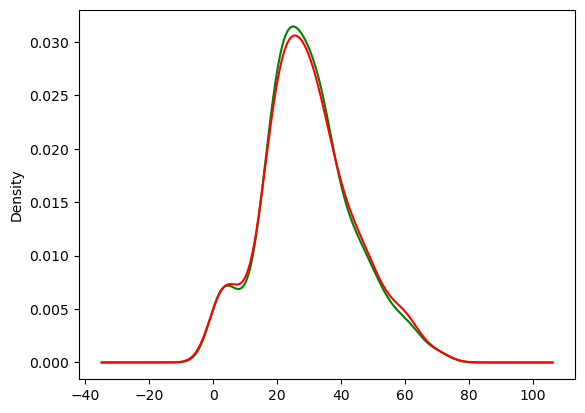

In [36]:
X_train['Age'].plot(kind='kde',color='green')
X_train['Age_imputed'].plot(kind='kde',color='red')

<Axes: >

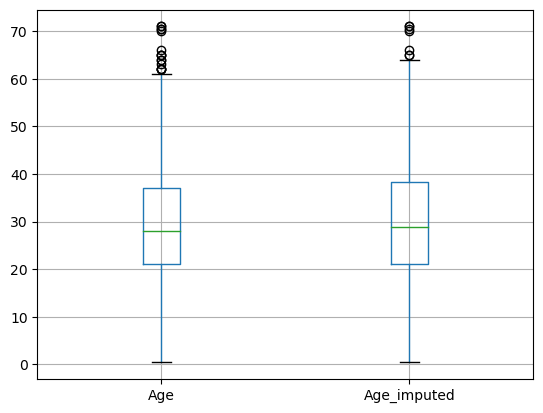

In [41]:
X_train[['Age','Age_imputed']].boxplot()

#### Categorical data

In [42]:
data = pd.read_csv('data/train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [43]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [44]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [45]:
X_train = data
y_test = data['SalePrice']

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)